In [1]:


df

,Chromosome,Count,TotalCount
0,1,90,1214
1,10,65,856
2,11,101,1370
3,12,43,768
4,13,57,773
5,14,51,632
6,15,60,694
7,16,42,549
8,17,58,893
9,18,38,496


In [1]:
import statsmodels
statsmodels.__version__

'0.13.1'

# NPCs day 5

In [18]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts.txt',
                delimiter='\t')

# Perform Fisher's exact test for each chromosome
p_values = []
for index, row in df.iterrows():
    print(row['Count'],sum(df['Count']) - row['Count'])
    contingency_table = [[row['Count'], row['TotalCount'] - row['Count']],
                         [sum(df['Count']) - row['Count'], sum(df['TotalCount']) - sum(df['Count']) - row['TotalCount'] + row['Count']]]
    _, p_value = fisher_exact(contingency_table)
    p_values.append(p_value)

print(p_values)
padj=multipletests(p_values, alpha=0.05,
                   method='fdr_bh',is_sorted=False, returnsorted=False)
print(padj[1])
# Add p-value column to the DataFrame
df['P_Value'] = p_values
df['FDR'] = padj[1]
# Save the updated DataFrame to a CSV file
# df.to_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/updated_gene_counts.csv', index=False)

90 1416
65 1441
101 1405
43 1463
57 1449
51 1455
60 1446
42 1464
58 1448
38 1468
46 1460
104 1402
126 1380
109 1397
103 1403
70 1436
93 1413
71 1435
60 1446
119 1387
[0.4447227885984607, 0.6993062528808084, 0.3801838828717564, 0.009883559343611556, 0.5430439140467799, 0.9407552344996585, 0.5226296215049171, 0.8110707622948234, 0.08835340412475239, 0.866929241976406, 0.9384999061332022, 0.17667403945373422, 3.1574005315201385e-07, 0.041794641665317406, 0.9577548011230808, 0.7548040178588605, 0.013968410110994412, 0.5409315386139297, 0.0024932747751893374, 2.185383494984115e-19]
[8.35452175e-01 9.57754801e-01 8.35452175e-01 4.94177967e-02
 8.35452175e-01 9.57754801e-01 8.35452175e-01 9.57754801e-01
 2.52438297e-01 9.57754801e-01 9.57754801e-01 4.41685099e-01
 3.15740053e-06 1.39315472e-01 9.57754801e-01 9.57754801e-01
 5.58736404e-02 8.35452175e-01 1.66218318e-02 4.37076699e-18]


In [17]:
import pandas as pd
from scipy.stats import fisher_exact

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts_UP.txt',
                delimiter='\t')

# Perform Fisher's exact test for each chromosome
p_values = []
for index, row in df.iterrows():
    contingency_table = [[row['Count'], row['TotalCount'] - row['Count']],
                         [sum(df['Count']) - row['Count'], sum(df['TotalCount']) - sum(df['Count']) - row['TotalCount'] + row['Count']]]
    _, p_value = fisher_exact(contingency_table)
    p_values.append(p_value)

print(p_values)
padj=multipletests(p_values, alpha=0.05,
                   method='fdr_bh',is_sorted=False, returnsorted=False)
print(padj[1])
# Add p-value column to the DataFrame
df['P_Value'] = p_values
df['FDR'] = padj[1]

# Save the updated DataFrame to a CSV file
df.to_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/updated_gene_counts_UP.csv', index=False)

[0.06644525480866238, 0.8541162764255966, 0.2517684947828164, 0.04293594837891919, 0.15751399941989921, 0.39395029863655007, 0.7642143780084506, 0.4866541490863038, 1.0, 0.16299575447079073, 0.5737944498226848, 0.8825062864150326, 3.8177956413848974e-05, 0.21719315458046684, 0.20861009866313093, 0.7239149632373032, 0.016129859182439227, 0.7892564391679676, 0.04726069229873374, 2.6605933954811248e-05]
[2.21484183e-01 9.28953986e-01 4.57760900e-01 1.89042769e-01
 4.07489386e-01 6.56583831e-01 9.28536987e-01 7.48698691e-01
 1.00000000e+00 4.07489386e-01 8.19706357e-01 9.28953986e-01
 3.81779564e-04 4.34386309e-01 4.34386309e-01 9.28536987e-01
 1.07532395e-01 9.28536987e-01 1.89042769e-01 3.81779564e-04]


In [18]:
import pandas as pd
from scipy.stats import fisher_exact

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts_DOWN.txt',
                delimiter='\t')

# Perform Fisher's exact test for each chromosome
p_values = []
for index, row in df.iterrows():
    contingency_table = [[row['Count'], row['TotalCount'] - row['Count']],
                         [sum(df['Count']) - row['Count'], sum(df['TotalCount']) - sum(df['Count']) - row['TotalCount'] + row['Count']]]
    _, p_value = fisher_exact(contingency_table)
    p_values.append(p_value)

print(p_values)
padj=multipletests(p_values, alpha=0.05,
                   method='fdr_bh',is_sorted=False, returnsorted=False)
print(padj[1])
# Add p-value column to the DataFrame
df['P_Value'] = p_values
df['FDR'] = padj[1]

# Save the updated DataFrame to a CSV file
df.to_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/updated_gene_counts_DOWN.csv', index=False)

[0.003370456779000091, 0.8560673859137223, 0.8888832038821697, 0.14909350663857346, 0.4903304779174749, 0.5283767905282977, 0.1515849844252234, 0.31949652533377904, 0.028531087093001617, 0.06495935947175309, 0.6708495444020557, 0.11663395407504581, 0.0021714104404757977, 0.08586703002426421, 0.4143758812085962, 1.0, 0.25320257281493586, 0.31201636459157994, 0.02758180601235541, 3.2718010137540942e-15]
[2.24697119e-02 9.35666530e-01 9.35666530e-01 3.03169969e-01
 6.53773971e-01 6.60470988e-01 3.03169969e-01 4.91533116e-01
 1.14124348e-01 2.16531198e-01 7.89234758e-01 2.91584885e-01
 2.17141044e-02 2.45334371e-01 5.91965545e-01 1.00000000e+00
 4.60368314e-01 4.91533116e-01 1.14124348e-01 6.54360203e-14]


# mESCs

In [15]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts_und.txt',
                delimiter='\t')

# Perform Fisher's exact test for each chromosome
p_values = []
odds_list=[]

for index, row in df.iterrows():
    print(row['Count'],sum(df['Count']) - row['Count'])
    contingency_table = [[row['Count'], row['TotalCount'] - row['Count']],
                         [sum(df['Count']) - row['Count'], sum(df['TotalCount']) - sum(df['Count']) - row['TotalCount'] + row['Count']]]
    odds, p_value = fisher_exact(contingency_table)
    odds_list.append(odds)
    p_values.append(p_value)

print(p_values)
padj=multipletests(p_values, alpha=0.05,
                   method='fdr_bh',is_sorted=False, returnsorted=False)
print(padj[1])
# Add p-value column to the DataFrame
df['P_Value'] = p_values
df['FDR'] = padj[1]
# Save the updated DataFrame to a CSV file
# df.to_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/updated_gene_counts_und.csv', index=False)

49 654
22 681
33 670
15 688
29 674
23 680
25 678
12 691
21 682
16 687
19 684
38 665
58 645
91 612
56 647
44 659
48 655
29 674
27 676
48 655
[0.3351139313810706, 0.05393027454302081, 0.0017825716468649327, 0.007732233887636122, 0.9242110342567109, 1.0, 0.8400368842699821, 0.04149506425412575, 0.010213725387362843, 0.8052398840614867, 0.5122277549101368, 0.03925752066134354, 0.0001882929165992409, 2.666949489998332e-11, 0.1643518578439241, 0.07155405426839007, 0.28597094318416566, 0.22338852035457102, 0.03620820722610534, 2.7679556531002506e-05]
[4.46818575e-01 1.07860549e-01 8.91285823e-03 3.09289356e-02
 9.72853720e-01 1.00000000e+00 9.33374316e-01 9.22112539e-02
 3.40457513e-02 9.33374316e-01 6.40284694e-01 9.22112539e-02
 1.25528611e-03 5.33389898e-10 2.73919763e-01 1.30098280e-01
 4.08529919e-01 3.43674647e-01 9.22112539e-02 2.76795565e-04]


In [16]:
df['odds']=odds_list
df

,Chromosome,Count,TotalCount,P_Value,FDR,odds
0,1,49,1061,3.351139e-01,4.468186e-01,1.155170
1,10,22,799,5.393027e-02,1.078605e-01,0.658499
2,11,33,1323,1.782572e-03,8.912858e-03,0.585127
3,12,15,695,7.732234e-03,3.092894e-02,0.510912
4,13,29,738,9.242110e-01,9.728537e-01,0.965279
5,14,23,576,1.000000e+00,1.000000e+00,0.982411
6,15,25,655,8.400369e-01,9.333743e-01,0.935583
7,16,12,522,4.149506e-02,9.221125e-02,0.548395
8,17,21,868,1.021373e-02,3.404575e-02,0.573229
9,18,16,433,8.052399e-01,9.333743e-01,0.904667


In [12]:
import pandas as pd
from scipy.stats import fisher_exact

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts_UP_und.txt',
                delimiter='\t')

# Perform Fisher's exact test for each chromosome
p_values = []
odds_list=[]
for index, row in df.iterrows():
    contingency_table = [[row['Count'], row['TotalCount'] - row['Count']],
                         [sum(df['Count']) - row['Count'], sum(df['TotalCount']) - sum(df['Count']) - row['TotalCount'] + row['Count']]]
    odds, p_value = fisher_exact(contingency_table)
    odds_list.append(odds)
    p_values.append(p_value)

print(p_values)
padj=multipletests(p_values, alpha=0.05,
                   method='fdr_bh',is_sorted=False, returnsorted=False)
print(padj[1])
# Add p-value column to the DataFrame
df['P_Value'] = p_values
df['FDR'] = padj[1]

# Save the updated DataFrame to a CSV file
# df.to_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/updated_gene_counts_UP_und.csv', index=False)

[0.03833974151466024, 0.7452825458478916, 0.9536164414635238, 0.9999275703625501, 0.17290703483820702, 0.4080307652411648, 0.8880075143298715, 0.820275523772684, 0.8110446517683506, 0.3540929960264477, 0.979685104116923, 0.8003831287414765, 9.058397709334038e-05, 9.62557232873215e-07, 0.8380442855979574, 0.025934734714412204, 0.99680602036438, 0.8611724113140294, 0.974671954309147, 0.15030237128909973]
[1.91698708e-01 9.99927570e-01 9.99927570e-01 9.99927570e-01
 5.76356783e-01 9.99927570e-01 9.99927570e-01 9.99927570e-01
 9.99927570e-01 9.99927570e-01 9.99927570e-01 9.99927570e-01
 9.05839771e-04 1.92511447e-05 9.99927570e-01 1.72898231e-01
 9.99927570e-01 9.99927570e-01 9.99927570e-01 5.76356783e-01]


In [13]:
odds_list

[1.5065357480988302,
 0.8547141312370197,
 0.688969764837626,
 0.16039025602783993,
 1.305624717066546,
 1.1162551707989699,
 0.687857427849448,
 0.7591283576268708,
 0.8044809982983551,
 1.1802439391657882,
 0.46619153141282865,
 0.8403028933092225,
 2.9626927639383154,
 2.4541015625,
 0.7931432166072552,
 1.61702615037842,
 0.4952742279020234,
 0.7548380726698263,
 0.5885671915825154,
 1.4390602055800295]

In [14]:
df['odds']=odds_list
df

,Chromosome,Count,TotalCount,P_Value,FDR,odds
0,1,26,504,3.833974e-02,0.191699,1.506536
1,10,13,419,7.452825e-01,0.999928,0.854714
2,11,18,702,9.536164e-01,0.999928,0.688970
3,12,2,326,9.999276e-01,0.999928,0.160390
4,13,18,394,1.729070e-01,0.576357,1.305625
5,14,11,277,4.080308e-01,0.999928,1.116255
6,15,8,317,8.880075e-01,0.999928,0.687857
7,16,8,289,8.202755e-01,0.999928,0.759128
8,17,13,443,8.110447e-01,0.999928,0.804481
9,18,10,239,3.540930e-01,0.999928,1.180244


In [11]:
df['odds']=odds_list
df

,Chromosome,Count,TotalCount,P_Value,FDR,odds
0,1,26,504,0.062247,0.207491,1.506536
1,10,13,419,0.686272,0.722391,0.854714
2,11,18,702,0.137941,0.306536,0.688970
3,12,2,326,0.001124,0.007493,0.160390
4,13,18,394,0.266813,0.485114,1.305625
5,14,11,277,0.740832,0.740832,1.116255
6,15,8,317,0.356903,0.594839,0.687857
7,16,8,289,0.626974,0.696638,0.759128
8,17,13,443,0.513124,0.641405,0.804481
9,18,10,239,0.594189,0.696638,1.180244


In [17]:
import pandas as pd
from scipy.stats import fisher_exact

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts_DOWN_und.txt',
                delimiter='\t')

# Perform Fisher's exact test for each chromosome
p_values = []
odds_list=[]
for index, row in df.iterrows():
    contingency_table = [[row['Count'], row['TotalCount'] - row['Count']],
                         [sum(df['Count']) - row['Count'], sum(df['TotalCount']) - sum(df['Count']) - row['TotalCount'] + row['Count']]]
    odds, p_value = fisher_exact(contingency_table)
    p_values.append(p_value)
    odds_list.append(odds)

print(p_values)
padj=multipletests(p_values, alpha=0.05,
                   method='fdr_bh',is_sorted=False, returnsorted=False)
print(padj[1])
# Add p-value column to the DataFrame
df['P_Value'] = p_values
df['FDR'] = padj[1]

# Save the updated DataFrame to a CSV file
# df.to_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/updated_gene_counts_DOWN_und.csv', index=False)

[0.7516693663009316, 0.041893889830583855, 0.006642397092879698, 0.44098790130822785, 0.28773075323199904, 0.7774921157359229, 0.5926471734446488, 0.03586030577023491, 0.005409084841124479, 0.48076983433556925, 0.5502412031125754, 0.036319111214283446, 0.09833187000917637, 2.3265696637196685e-06, 0.022007036044810795, 0.545103870763904, 0.6436756837702513, 0.4869105381360796, 0.3022023410201504, 2.6464541816011486e-05]
[7.77492116e-01 1.04734725e-01 3.32119855e-02 6.87801504e-01
 5.49458802e-01 7.77492116e-01 6.97231969e-01 1.03768889e-01
 3.32119855e-02 6.87801504e-01 6.87801504e-01 1.03768889e-01
 2.18515267e-01 4.65313933e-05 8.80281442e-02 6.87801504e-01
 7.15195204e-01 6.87801504e-01 5.49458802e-01 2.64645418e-04]


In [18]:
df['odds']=odds_list
df

,Chromosome,Count,TotalCount,P_Value,FDR,odds
0,1,23,558,0.751669,0.777492,0.906763
1,10,9,380,0.041894,0.104735,0.503585
2,11,15,621,0.006642,0.033212,0.506788
3,12,13,370,0.440988,0.687802,0.764986
4,13,11,344,0.287731,0.549459,0.692430
5,14,12,299,0.777492,0.777492,0.883609
6,15,17,338,0.592647,0.697232,1.129025
7,16,4,233,0.035860,0.103769,0.364273
8,17,8,425,0.005409,0.033212,0.395010
9,18,6,194,0.480770,0.687802,0.672223


# Take gene density into account

In [1]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts_with_density.txt',
                delimiter='\t')

df

,Chromosome,Count,len,lenMB,gene_density
0,1,90,195471971,195.471971,17.537041
1,10,65,130694993,130.694993,20.016069
2,11,101,122082543,122.082543,24.450670
3,12,43,120129022,120.129022,20.519604
4,13,57,120421639,120.421639,20.710563
5,14,51,124902244,124.902244,20.215810
6,15,60,104043685,104.043685,17.742547
7,16,42,98207768,98.207768,16.322538
8,17,58,94987271,94.987271,24.403270
9,18,38,90702639,90.702639,15.368902


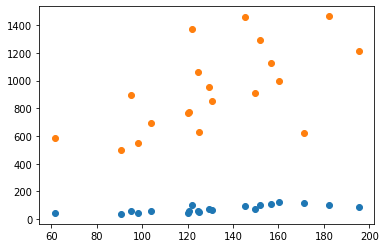

In [31]:
import matplotlib.pyplot as plt

plt.scatter(df["lenMB"],df["Count"])
plt.scatter(df["lenMB"],df["TotalCount"])

In [29]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Read the DataFrame from a CSV file
df = pd.read_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/gene_counts_with_density.txt',
                delimiter='\t')

# Calculate the scaling factor for each chromosome
scaling_factor = df['TotalCount'].sum() / (df['gene_density'] * df['lenMB']).sum()
print(scaling_factor)

# Calculate the expected count based on gene density and scaling factor
df['ExpectedCount'] = df['gene_density'] * df['len'] * scaling_factor

# Perform Fisher's exact test for each chromosome
p_values = []
for index, row in df.iterrows():
    # Contingency table with observed and expected counts
    contingency_table = [[row['Count'], row['TotalCount'] - row['Count']],
                         [row['ExpectedCount'], row['TotalCount'] * row['lenMB'] - row['ExpectedCount']]]
    _, p_value = fisher_exact(contingency_table)
    p_values.append(p_value)

# Perform multiple testing correction
padj = multipletests(p_values, alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)

# Add p-value and FDR columns to the DataFrame
df['P_Value'] = p_values
df['FDR'] = padj[1]

# Filter for significantly enriched clusters based on FDR
significantly_enriched = df[df['FDR'] < 0.05]

# Save the updated DataFrame to a CSV file
# df.to_csv('updated_data.csv', index=False)
# significantly_enriched.to_csv('significantly_enriched_clusters.csv', index=False)

df

0.34924098317854607


ValueError: All values in `table` must be nonnegative.

In [32]:
data=pd.read_excel("/Users/jonathan/Desktop/CDQ_VILLA_CERTOSA/CAMPAGNA_CROWDFUNDING/REPORT_FINALE_DONAZIONI/progetto33638.xlsx")

In [46]:
names=list(data[data.Reward=="Grazie!"]["Name"])
surnames=list(data[data.Reward=="Grazie!"]["Surname"])



In [49]:
grazie=[i+" "+j for (i,j) in zip(names,surnames)]

In [50]:
grazie

['vanessa bilancetti',
 'anahi mariotti',
 'Daniele Fischer',
 'cristina nobili',
 'Leonardo Marcello Pignataro',
 'Elisabetta Torregiani',
 'Valerio Cinque',
 'Cristina Marianello',
 'sergio sarritzu',
 'simona tili',
 'Bianca Vallarano',
 'Marco Giampetruzzi']

In [36]:
import numpy as np

np.savetxt("mailing_list_graziedautrice.txt",np.c_[list(data[data.Reward=="Grazie d'autrice"].Email)],fmt="%s")

In [40]:
np.savetxt("mailing_list_PDB_SENZAgraziedautrice.txt",np.c_[list(data[data.Reward!="Grazie d'autrice"].Email)],fmt="%s")


In [ ]:
df.to_csv('/Users/jonathan/Desktop/IIT/Cerase_single_cell/bulk_RNA_seq/analysis_results_MAY_2023/updated_gene_counts.csv', index=False)

